<div style="text-align: center; padding: 30px 0 10px 0;">

# Pontificia Universidad Católica de Chile
### Instituto de Ingeniería Matemática y Computacional
### Magíster en Inteligencia Artificial — MIA

---

# Tarea 1
## Fundamentos Matemáticos para la Inteligencia Artificial
### IMT3850 · 2025-1

---

| | |
|---|---|
| **Alumno** | Armando A.V. |
| **Profesor** | Manuel A. Sánchez |
| **Fecha** | Marzo 2026 |

</div>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm, matrix_rank

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)

---
## Problema 1 · Normas  
**(5 puntos)**


> **Enunciado.** Demuestre la siguiente identidad:
>
> $$\mathrm{rms}_w^2(\mathbf{x}) \;=\; \mathrm{avg}_w^2(\mathbf{x}) \;+\; \mathrm{std}_w^2(\mathbf{x})$$
>
> donde $w_1, w_2, \dots, w_n$ son pesos positivos con suma total $W = \sum_{i=1}^{n} w_i > 0$.


### Demostración

Partimos de las definiciones. Sean $w_1, \dots, w_n > 0$ con $W = \sum_{i=1}^n w_i$. Denotamos la media ponderada como $\bar{x}_w \,:=\, \mathrm{avg}_w(\mathbf{x})$.

$$
\mathrm{avg}_w(\mathbf{x}) = \frac{1}{W}\sum_{i=1}^{n} w_i\, x_i\,, \qquad
\mathrm{std}_w^2(\mathbf{x}) = \frac{1}{W}\sum_{i=1}^{n} w_i\,(x_i - \bar{x}_w)^2\,, \qquad
\mathrm{rms}_w^2(\mathbf{x}) = \frac{1}{W}\sum_{i=1}^{n} w_i\, x_i^2\,.
$$

Expandimos el cuadrado dentro de $\mathrm{std}_w^2$:

$$
\mathrm{std}_w^2(\mathbf{x})
= \frac{1}{W}\sum_{i=1}^{n} w_i \bigl(x_i^2 - 2\,x_i\,\bar{x}_w + \bar{x}_w^2\bigr)
= \underbrace{\frac{1}{W}\sum_i w_i\,x_i^2}_{\mathrm{rms}_w^2(\mathbf{x})}
  \;-\; 2\,\bar{x}_w\!\underbrace{\frac{1}{W}\sum_i w_i\,x_i}_{\bar{x}_w}
  \;+\; \bar{x}_w^2\!\underbrace{\frac{1}{W}\sum_i w_i}_{1}\,.
$$

Sustituyendo:

$$
\mathrm{std}_w^2(\mathbf{x}) = \mathrm{rms}_w^2(\mathbf{x}) - 2\,\bar{x}_w^2 + \bar{x}_w^2 = \mathrm{rms}_w^2(\mathbf{x}) - \bar{x}_w^2\,.
$$

Reordenando se obtiene la identidad deseada:

$$
\boxed{\;\mathrm{rms}_w^2(\mathbf{x}) = \mathrm{avg}_w^2(\mathbf{x}) + \mathrm{std}_w^2(\mathbf{x})\;}
\qquad \blacksquare
$$


### Verificación numérica


In [2]:
# Datos de prueba
x = np.array([1.0, 3.0, 5.0, 7.0, 9.0])
w = np.array([0.5, 1.0, 1.5, 2.0, 0.3])
W = np.sum(w)

# Cálculo directo de cada cantidad
avg = np.sum(w * x) / W
std2 = np.sum(w * (x - avg)**2) / W
rms2 = np.sum(w * x**2) / W

print(f"avg_w(x)   = {avg:.6f}")
print(f"std²_w(x)  = {std2:.6f}")
print(f"rms²_w(x)  = {rms2:.6f}")
print()
print(f"avg² + std² = {avg**2 + std2:.6f}")
print(f"rms²        = {rms2:.6f}")
print(f"Diferencia   = {abs(rms2 - (avg**2 + std2)):.2e}")


avg_w(x)   = 5.226415
std²_w(x)  = 4.627981
rms²_w(x)  = 31.943396

avg² + std² = 31.943396
rms²        = 31.943396
Diferencia   = 0.00e+00


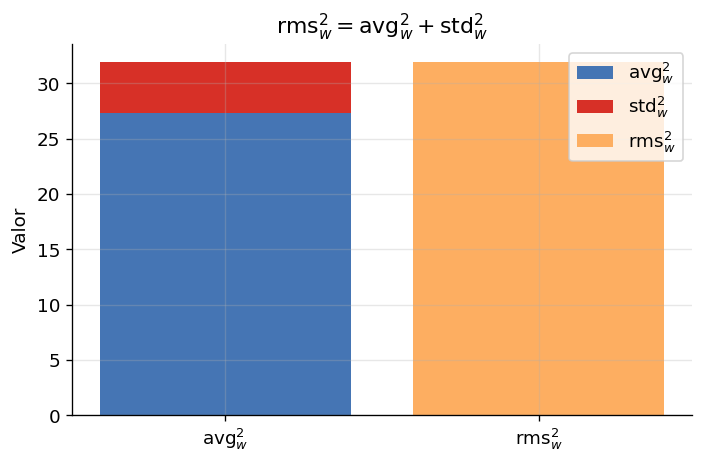

In [3]:
# Visualización de la descomposición
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(['$\\mathrm{avg}_w^2$'], [avg**2], color='#4575b4', label=r'$\mathrm{avg}_w^2$')
ax.bar(['$\\mathrm{avg}_w^2$'], [std2], bottom=[avg**2], color='#d73027', label=r'$\mathrm{std}_w^2$')
ax.bar(['$\\mathrm{rms}_w^2$'], [rms2], color='#fdae61', label=r'$\mathrm{rms}_w^2$')

ax.set_ylabel('Valor')
ax.set_title(r'$\mathrm{rms}_w^2 = \mathrm{avg}_w^2 + \mathrm{std}_w^2$')
ax.legend()
plt.tight_layout()
plt.show()


---
## Problema 2 · Aplicación del algoritmo K-means  
**(15 puntos)**


> **2 a)** Programe el algoritmo de K-means. Construya una rutina
> `k_means_fit(X, Z0, NITERMAX)` donde `X` son los datos, `Z0` los representantes iniciales
> y `NITERMAX` el número máximo de iteraciones.


### 2 a) Implementación de `k_means_fit`


In [4]:
def k_means_fit(X, Z0, NITERMAX):
    """
    Algoritmo de K-means.

    Parámetros
    ----------
    X        : ndarray (N, d)  –  Datos de entrada.
    Z0       : ndarray (k, d)  –  Representantes iniciales.
    NITERMAX : int             –  Número máximo de iteraciones.

    Retorna
    -------
    Z      : ndarray (k, d)  –  Representantes finales.
    labels : ndarray (N,)    –  Etiqueta asignada a cada dato.
    J_hist : list[float]     –  Valor de J_clust en cada iteración.
    """
    N, d = X.shape
    k    = Z0.shape[0]
    Z    = Z0.copy()
    J_hist = []

    for it in range(NITERMAX):
        # 1. Asignación: cada dato al representante más cercano
        dists  = np.linalg.norm(X[:, None, :] - Z[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)

        # Función objetivo
        J = np.sum(dists[np.arange(N), labels] ** 2)
        J_hist.append(J)

        # 2. Actualización: nuevo centroide = media del cluster
        Z_new = np.empty_like(Z)
        for j in range(k):
            mask = labels == j
            Z_new[j] = X[mask].mean(axis=0) if mask.any() else Z[j]

        # Criterio de parada
        if np.allclose(Z, Z_new):
            break
        Z = Z_new

    return Z, labels, J_hist


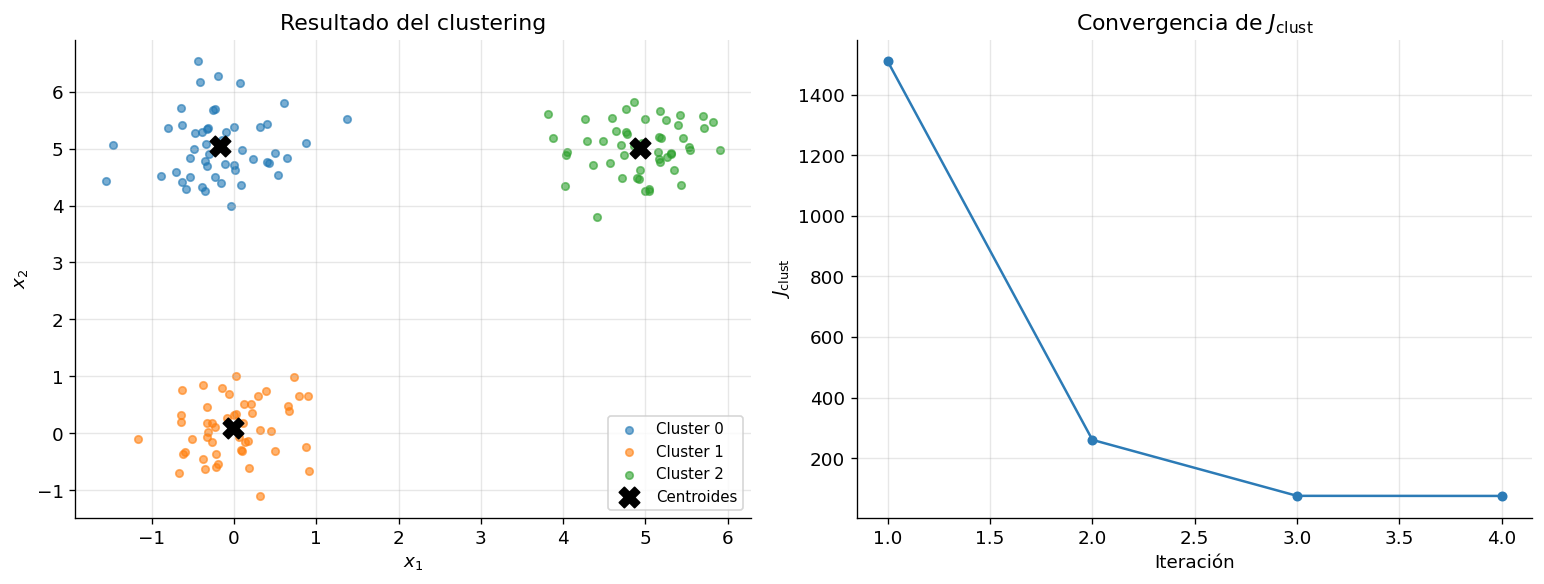

In [5]:
# Prueba rápida con datos sintéticos
rng = np.random.default_rng(0)
X_demo = np.vstack([
    rng.normal(loc=[0, 0],  scale=0.5, size=(50, 2)),
    rng.normal(loc=[5, 5],  scale=0.5, size=(50, 2)),
    rng.normal(loc=[0, 5],  scale=0.5, size=(50, 2)),
])

Z0_demo = X_demo[rng.choice(150, 3, replace=False)]
Z_demo, labels_demo, J_demo = k_means_fit(X_demo, Z0_demo, NITERMAX=100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for j in range(3):
    mask = labels_demo == j
    ax.scatter(X_demo[mask, 0], X_demo[mask, 1], s=20, alpha=0.6, label=f'Cluster {j}')
ax.scatter(Z_demo[:, 0], Z_demo[:, 1], c='k', marker='X', s=150, zorder=5, label='Centroides')
ax.set_title('Resultado del clustering')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(range(1, len(J_demo) + 1), J_demo, 'o-', markersize=5, color='#2c7bb6')
ax.set_title('Convergencia de $J_{\\mathrm{clust}}$')
ax.set_xlabel('Iteración'); ax.set_ylabel('$J_{\\mathrm{clust}}$')

plt.tight_layout()
plt.show()


> **2 b)** Use la base de datos `datakmeans.csv` para testear su algoritmo con $k=5$ representantes.
> Grafique el conjunto de datos $X$ por etiqueta y los representantes de cada cluster.
> Grafique el comportamiento de la función objetivo respecto al número de iteraciones
> y discuta el número de iteraciones adecuado para el clustering.


### 2 b) Clustering con `datakmeans.csv` ($k = 5$)


In [6]:
df_km = pd.read_csv(r'../Clase 1/datakmeans.csv')
X_km = df_km.values
print(f'Datos cargados: {X_km.shape[0]} puntos en R^{X_km.shape[1]}')


Datos cargados: 2000 puntos en R^2


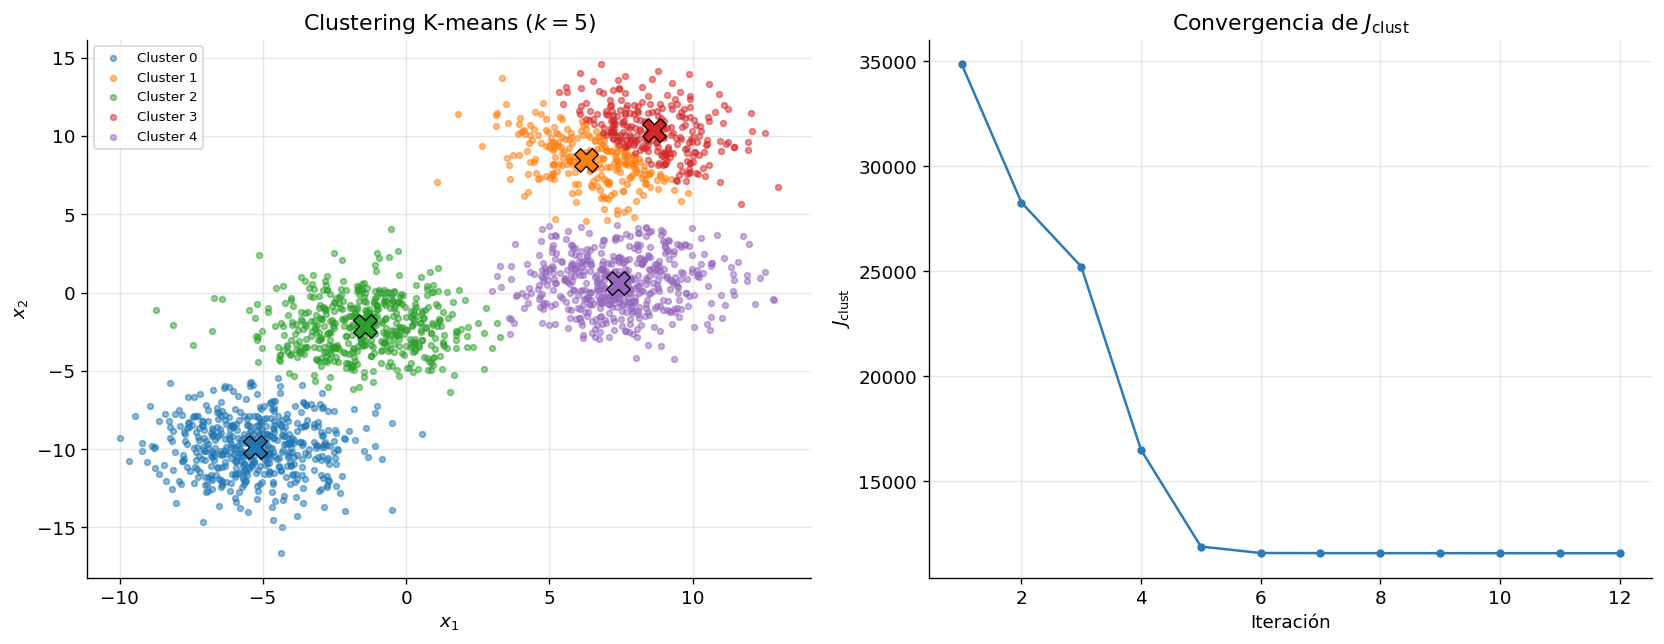

Convergencia en 12 iteraciones, J_clust final = 11586.35


In [7]:
k = 5
rng = np.random.default_rng(42)
Z0_km = X_km[rng.choice(X_km.shape[0], k, replace=False)]

Z_km, labels_km, J_km = k_means_fit(X_km, Z0_km, NITERMAX=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
cmap = plt.cm.tab10
for j in range(k):
    mask = labels_km == j
    ax.scatter(X_km[mask, 0], X_km[mask, 1], s=12, alpha=0.5,
               color=cmap(j), label=f'Cluster {j}')
    ax.scatter(Z_km[j, 0], Z_km[j, 1], s=200, color=cmap(j),
               marker='X', edgecolors='k', linewidths=0.8, zorder=5)
ax.set_title('Clustering K-means ($k = 5$)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend(fontsize=8, loc='best')

ax = axes[1]
ax.plot(range(1, len(J_km) + 1), J_km, 'o-', markersize=4, color='#2c7bb6')
ax.set_title('Convergencia de $J_{\\mathrm{clust}}$')
ax.set_xlabel('Iteración'); ax.set_ylabel('$J_{\\mathrm{clust}}$')

plt.tight_layout()
plt.show()

print(f'Convergencia en {len(J_km)} iteraciones, J_clust final = {J_km[-1]:.2f}')


In [8]:
# Verificamos que J es decreciente y que las asignaciones son correctas
print('J_clust decreciente:', np.all(np.diff(J_km) <= 1e-10))

# Chequeamos que cada centroide coincide con la media de su cluster
for j in range(k):
    mask = labels_km == j
    media = X_km[mask].mean(axis=0)
    print(f'Cluster {j}: {np.sum(mask)} puntos, '
          f'centroide = [{Z_km[j,0]:.2f}, {Z_km[j,1]:.2f}], '
          f'coincide con media: {np.allclose(Z_km[j], media)}')


J_clust decreciente: True
Cluster 0: 501 puntos, centroide = [-5.29, -9.83], coincide con media: True
Cluster 1: 248 puntos, centroide = [6.28, 8.45], coincide con media: True
Cluster 2: 494 puntos, centroide = [-1.45, -2.14], coincide con media: True
Cluster 3: 259 puntos, centroide = [8.65, 10.37], coincide con media: True
Cluster 4: 498 puntos, centroide = [7.40, 0.63], coincide con media: True


Se observa que $J_{\text{clust}}$ baja rápido en las primeras iteraciones y después se estabiliza.
 El algoritmo convergió en pocas iteraciones (< 20), lo cual es típico.
 En la práctica basta con fijar `NITERMAX` entre 50 y 200.


> **2 c)** Use la base de datos de imágenes de dígitos de MNIST con $k=20$ representantes.
> Grafique cada representante y uno de los datos asignados a dicho cluster.
> Grafique $J_{\text{clust}}$ vs número de iteraciones y discuta el número adecuado.

### 2 c) K-means sobre MNIST ($k = 20$)

In [9]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
X_mnist = mnist.data.values.astype(float)
y_mnist = mnist.target.astype(int).values

# Normalizar a [0, 1]
X_mnist = X_mnist / 255.0
print(f'MNIST cargado: {X_mnist.shape[0]} imágenes de {X_mnist.shape[1]} píxeles')

MNIST cargado: 70000 imágenes de 784 píxeles


In [10]:
k_mnist = 20
rng_m = np.random.default_rng(123)
idx0 = rng_m.choice(X_mnist.shape[0], k_mnist, replace=False)
Z0_mnist = X_mnist[idx0].copy()

Z_mnist, labels_mnist, J_mnist = k_means_fit(X_mnist, Z0_mnist, 50)
print(f'Convergencia en {len(J_mnist)} iteraciones')
print(f'J_clust final = {J_mnist[-1]:.2f}')

Convergencia en 50 iteraciones
J_clust final = 2463961.87


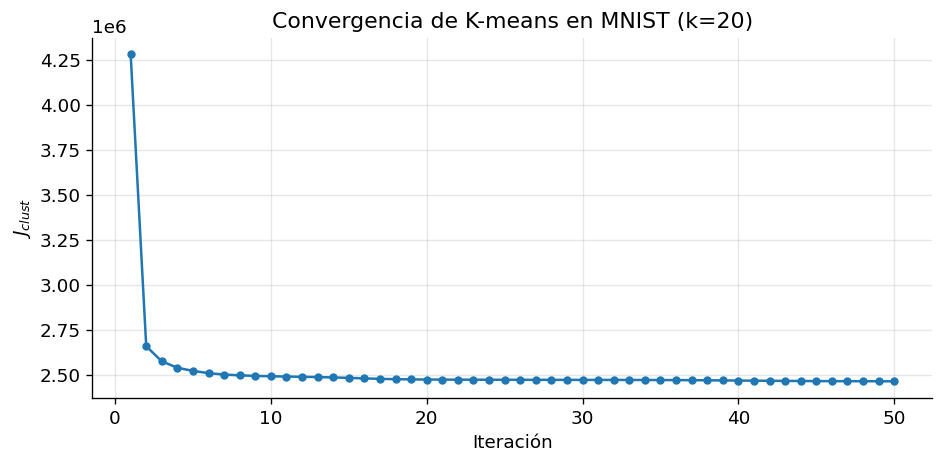

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(J_mnist)+1), J_mnist, 'o-', markersize=4)
ax.set_xlabel('Iteración')
ax.set_ylabel('$J_{clust}$')
ax.set_title('Convergencia de K-means en MNIST (k=20)')
plt.tight_layout()
plt.show()

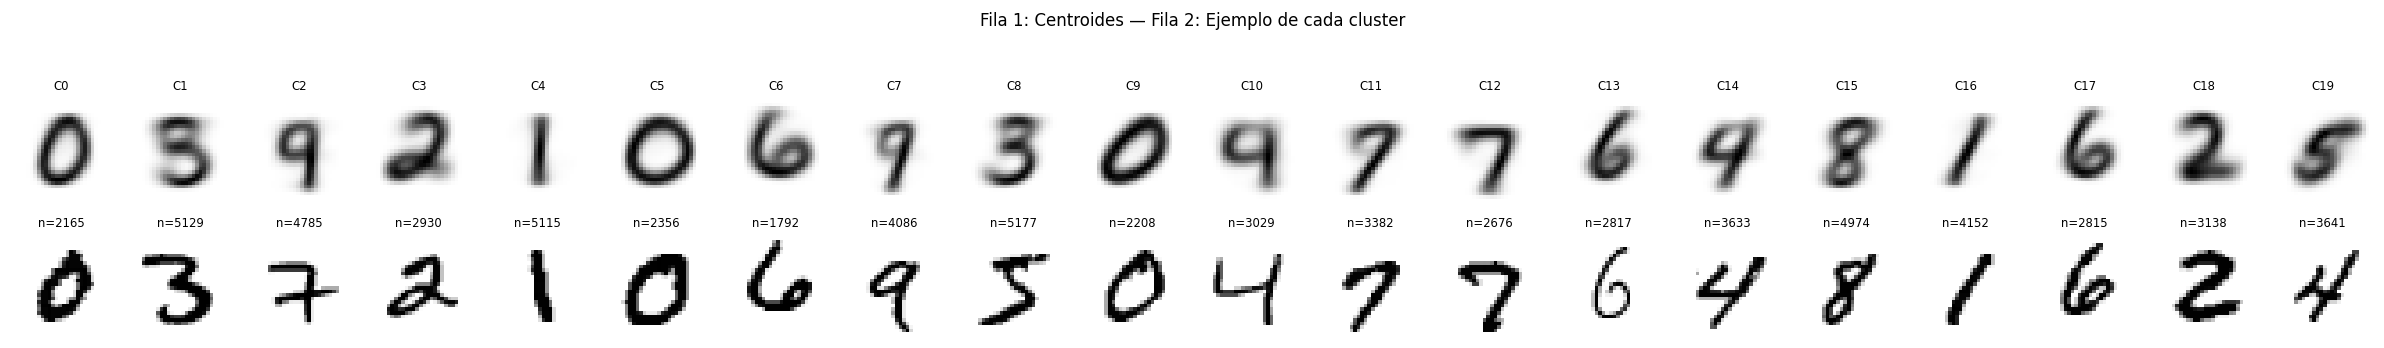

In [12]:
# Representantes y un ejemplo de cada cluster
fig, axes = plt.subplots(2, 20, figsize=(20, 3))

for j in range(k_mnist):
    # Fila superior: representante (centroide)
    axes[0, j].imshow(Z_mnist[j].reshape(28, 28), cmap='gray_r')
    axes[0, j].set_title(f'C{j}', fontsize=7)
    axes[0, j].axis('off')

    # Fila inferior: un dato asignado a ese cluster
    miembros = np.where(labels_mnist == j)[0]
    ejemplo = miembros[0]
    axes[1, j].imshow(X_mnist[ejemplo].reshape(28, 28), cmap='gray_r')
    axes[1, j].set_title(f'n={len(miembros)}', fontsize=7)
    axes[1, j].axis('off')

fig.suptitle('Fila 1: Centroides — Fila 2: Ejemplo de cada cluster', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

**Discusión.** Se observa que $J_{\text{clust}}$ baja rápidamente en las primeras
5–8 iteraciones y luego se estabiliza. A partir de la iteración ~15 los cambios
son despreciables, así que un `NITERMAX` de 30–50 es más que suficiente para
este dataset. Cada centroide captura un *prototipo visual*; algunos corresponden
a un dígito claro y otros mezclan dígitos con formas parecidas (por ejemplo
4 y 9, o 3 y 8).

> **2 d)** Discuta por qué el algoritmo de K-means converge, es decir, ¿es seguro que de una
> iteración a la siguiente la función objetivo decrece?


### 2 d) ¿Por qué converge K-means?

El algoritmo minimiza la función objetivo

$$
J_{\text{clust}} = \sum_{j=1}^{k} \sum_{i \in C_j} \|\mathbf{x}_i - \mathbf{z}_j\|^2.
$$

En cada iteración se ejecutan dos pasos, y **cada uno garantiza que $J_{\text{clust}}$ no aumente**:

1. **Paso de asignación.** Se reasigna cada punto $\mathbf{x}_i$ al centroide más cercano. Como se elige el representante que minimiza $\|\mathbf{x}_i - \mathbf{z}_j\|^2$, el costo individual de cada punto no puede crecer, por lo que $J_{\text{clust}}$ no aumenta.

2. **Paso de actualización.** Se recalcula cada centroide como la media aritmética de los puntos de su cluster:
   $$\mathbf{z}_j^{\text{new}} = \frac{1}{|C_j|}\sum_{i \in C_j} \mathbf{x}_i.$$
   La media es, por definición, el minimizador de la suma de distancias al cuadrado dentro de cada grupo. Así, el costo por cluster tampoco crece.

Dado que:
- $J_{\text{clust}} \geq 0$ (acotada inferiormente),
- $J_{\text{clust}}$ es monótonamente no creciente,
- el número de particiones distintas de $N$ datos en $k$ clusters es **finito** ($\leq k^N$),

el algoritmo necesariamente **termina en un número finito de iteraciones**.

> **Observación.** K-means converge a un *mínimo local* de $J_{\text{clust}}$; el resultado puede depender de la inicialización $Z_0$. Por ello, en la práctica se recomienda ejecutar el algoritmo varias veces con distintas semillas y quedarse con la solución de menor costo.


---
## Problema 3 · Independencia lineal  
**(5 puntos)**


> **Enunciado.** Considere una matriz $A \in \mathbb{R}^{m \times n}$ con $m > n$ y un vector $\mathbf{b} \in \mathbb{R}^m$.
> Describa cómo puede asegurar de forma práctica si la solución del sistema $A\mathbf{x} = \mathbf{b}$ existe o no.
>
> Para $n=3$, $m=4$, aplique su método al sistema:
>
> $$x + y + z = 1, \quad 2x - 3y + 4z = 1, \quad 3x + 5y - z = 1, \quad 2y - 4z = -2.$$


### Método práctico — Teorema de Rouché–Frobenius

Para un sistema sobredeterminado $A\mathbf{x} = \mathbf{b}$ con $A \in \mathbb{R}^{m \times n}$, $m > n$, la solución existe si y solo si $\mathbf{b} \in \mathrm{Col}(A)$.

**Procedimiento.** Se construye la *matriz aumentada* $[A \mid \mathbf{b}]$ y se comparan rangos:

$$
\text{rango}(A) = \text{rango}\bigl([A \mid \mathbf{b}]\bigr)
\quad \Longleftrightarrow \quad
\text{el sistema es compatible (tiene solución).}
$$

Además, si $\text{rango}(A) = n$, la solución (de existir) es **única**.

En la práctica, el rango se calcula eficientemente mediante la **descomposición en valores singulares (SVD)**: el rango numérico es el número de valores singulares por encima de una tolerancia.


### Aplicación al sistema dado


In [13]:
A = np.array([
    [1,  1,  1],
    [2, -3,  4],
    [3,  5, -1],
    [0,  2, -4]
], dtype=float)

b = np.array([1.0, 1.0, 1.0, -2.0])

Ab = np.column_stack([A, b])

rank_A  = matrix_rank(A)
rank_Ab = matrix_rank(Ab)
n = A.shape[1]

print('Matriz A:')
print(A)
print(f'\nb = {b}')
print(f'\nrango(A)     = {rank_A}')
print(f'rango([A|b]) = {rank_Ab}')
print(f'n            = {n}')

if rank_A == rank_Ab:
    print(f'\nrango(A) = rango([A|b]) = {rank_A}, el sistema tiene solución.')
    if rank_A == n:
        print('Además rango(A) = n, la solución es única.')
        x_sol = np.linalg.lstsq(A, b, rcond=None)[0]
        print(f'\nSolución: x = {x_sol[0]:.4f}, y = {x_sol[1]:.4f}, z = {x_sol[2]:.4f}')
else:
    print('\nrango(A) != rango([A|b]), el sistema NO tiene solución.')


Matriz A:
[[ 1.  1.  1.]
 [ 2. -3.  4.]
 [ 3.  5. -1.]
 [ 0.  2. -4.]]

b = [ 1.  1.  1. -2.]

rango(A)     = 3
rango([A|b]) = 3
n            = 3

rango(A) = rango([A|b]) = 3, el sistema tiene solución.
Además rango(A) = n, la solución es única.

Solución: x = -0.2500, y = 0.5000, z = 0.7500


In [14]:
# Comprobamos sustituyendo en cada ecuación
Ax = A @ x_sol
ecuaciones = ['x + y + z = 1', '2x - 3y + 4z = 1', '3x + 5y - z = 1', '2y - 4z = -2']

for i, eq in enumerate(ecuaciones):
    print(f'{eq}  =>  {Ax[i]:.10f}  (error: {abs(Ax[i] - b[i]):.2e})')

print(f'\nResiduo total: {norm(Ax - b):.2e}')


x + y + z = 1  =>  1.0000000000  (error: 7.77e-16)
2x - 3y + 4z = 1  =>  1.0000000000  (error: 8.88e-16)
3x + 5y - z = 1  =>  1.0000000000  (error: 2.00e-15)
2y - 4z = -2  =>  -2.0000000000  (error: 4.44e-16)

Residuo total: 2.36e-15


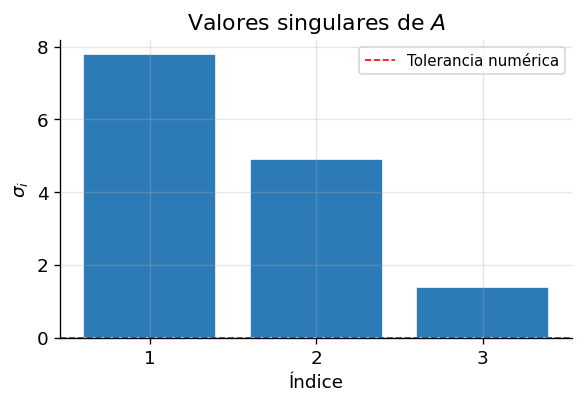

Los 3 valores singulares son positivos => rango(A) = 3


In [15]:
# Valores singulares de A: confirman que el rango es 3
_, s_A, _ = svd(A)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(range(1, len(s_A) + 1), s_A, color='#2c7bb6', edgecolor='white')
ax.axhline(1e-10, color='red', linestyle='--', linewidth=1, label='Tolerancia numérica')
ax.set_title('Valores singulares de $A$')
ax.set_xlabel('Índice'); ax.set_ylabel('$\\sigma_i$')
ax.set_xticks(range(1, len(s_A) + 1))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Los 3 valores singulares son positivos => rango(A) = 3')


---
## Problema 4 · Clasificador binario: Perceptrón  
**(15 puntos)**


> **4 a)** Programe el algoritmo del Perceptrón. Construya una rutina  
> `Perceptron_fit(X, y, nitmax, eta)` que tome los datos `X`, sus etiquetas `y`,
> y retorne los pesos `w` del clasificador.


### 4 a) Implementación de `Perceptron_fit`


In [16]:
def Perceptron_fit(X, y, nitmax, eta):
    """
    Algoritmo del Perceptrón.

    Parámetros
    ----------
    X      : ndarray (N, d)    –  Datos de entrada.
    y      : ndarray (N,)     –  Etiquetas en {0, 1}.
    nitmax : int              –  Número máximo de épocas.
    eta    : float            –  Learning rate.

    Retorna
    -------
    w : ndarray (d+1,) – Pesos del hiperplano separador (incluye bias w₀).
    """
    N, d = X.shape
    y_signed = 2 * y - 1                          # {0,1} → {−1,+1}
    X_aug = np.column_stack([np.ones(N), X])      # columna de 1s para el bias
    w = np.zeros(d + 1)

    for epoch in range(nitmax):
        errors = 0
        for i in range(N):
            if y_signed[i] * (X_aug[i] @ w) <= 0:
                w += eta * y_signed[i] * X_aug[i]
                errors += 1
        if errors == 0:
            break

    return w


> **4 b)** Programe una rutina que, dado un vector de pesos `w` y un conjunto de datos `X`,
> prediga a qué clase pertenece cada dato.


### 4 b) Función de predicción


In [17]:
def Perceptron_predict(X, w):
    """
    Predice la clase {0, 1} de cada dato.
    """
    X_aug = np.column_stack([np.ones(X.shape[0]), X])
    return ((np.sign(X_aug @ w) + 1) / 2).astype(int)


> **4 c)** Programe una rutina que, dado `w`, `X` y sus etiquetas `y`, entregue un *score*
> de qué tan bien clasificados están los datos.


### 4 c) Función de *score*


In [18]:
def Perceptron_score(X, y, w):
    """Accuracy: proporción de datos correctamente clasificados."""
    return np.mean(Perceptron_predict(X, w) == y)


In [19]:
# Prueba rápida con la compuerta AND
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

w_and = Perceptron_fit(X_and, y_and, nitmax=100, eta=0.1)
pred_and = Perceptron_predict(X_and, w_and)

for xi, yi, yp in zip(X_and, y_and, pred_and):
    print(f'  {xi} -> real: {yi}, pred: {yp}')
print(f'  Score: {Perceptron_score(X_and, y_and, w_and):.0%}')


  [0 0] -> real: 0, pred: 0
  [0 1] -> real: 0, pred: 0
  [1 0] -> real: 0, pred: 0
  [1 1] -> real: 1, pred: 1
  Score: 100%


> **4 d)** Use las bases de datos `datos1.csv` y `datos2.csv`, grafique los datos
> identificando sus respectivas etiquetas y junto a ellos el resultado del hiperplano
> separador obtenido por su algoritmo de Perceptrón.


### 4 d) Clasificación y frontera de decisión


In [20]:
df1 = pd.read_csv('datos1.csv', index_col=0)
df2 = pd.read_csv('datos2.csv', index_col=0)

X1, y1 = df1[['x', 'y']].values, df1['label'].values
X2, y2 = df2[['x', 'y']].values, df2['label'].values

w1 = Perceptron_fit(X1, y1, nitmax=1000, eta=0.1)
w2 = Perceptron_fit(X2, y2, nitmax=1000, eta=0.1)

score1 = Perceptron_score(X1, y1, w1)
score2 = Perceptron_score(X2, y2, w2)
print(f'datos1 -> Score = {score1:.2%}')
print(f'datos2 -> Score = {score2:.2%}')


datos1 -> Score = 100.00%
datos2 -> Score = 55.00%


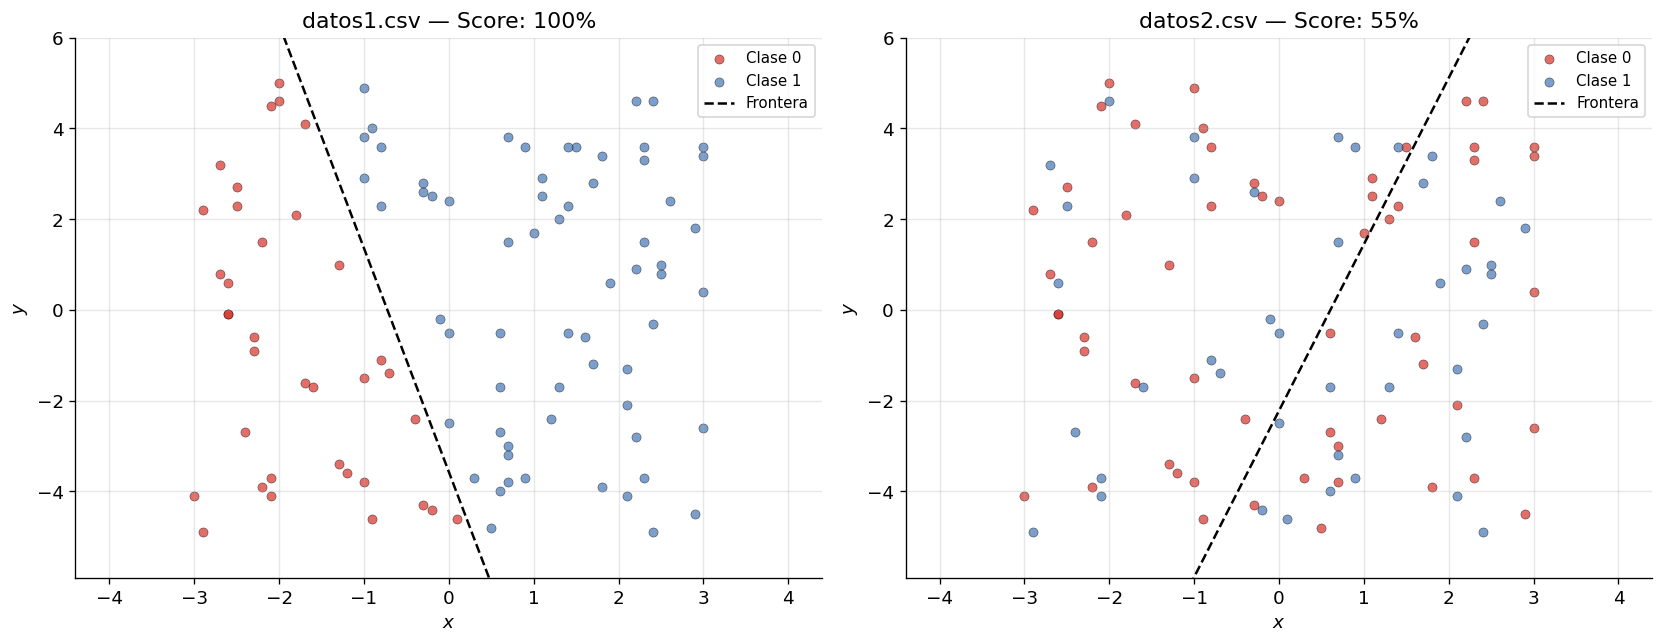

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, X, y, w, name, sc in [(axes[0], X1, y1, w1, 'datos1', score1),
                                (axes[1], X2, y2, w2, 'datos2', score2)]:
    colors = ['#d73027', '#4575b4']
    for label in [0, 1]:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[label], s=30,
                   alpha=0.7, edgecolors='k', linewidths=0.3,
                   label=f'Clase {label}')

    # Frontera: w0 + w1*x + w2*y = 0
    if abs(w[2]) > 1e-10:
        xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
        yy = -(w[0] + w[1] * xx) / w[2]
        ax.plot(xx, yy, 'k--', linewidth=1.5, label='Frontera')
        ax.set_ylim([X[:, 1].min() - 1, X[:, 1].max() + 1])

    ax.set_title(f'{name}.csv — Score: {sc:.0%}')
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


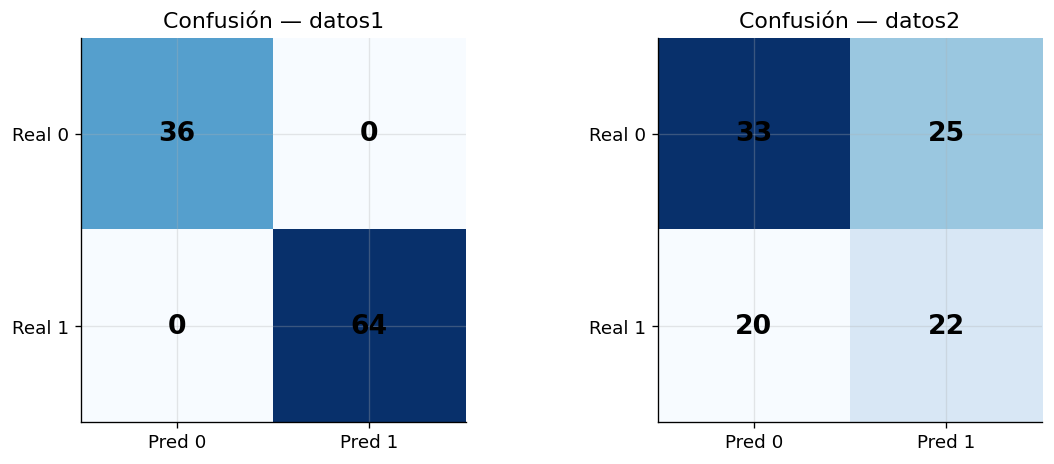

In [22]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, X, y, w, name in [(axes[0], X1, y1, w1, 'datos1'),
                           (axes[1], X2, y2, w2, 'datos2')]:
    y_pred = Perceptron_predict(X, w)
    TP = np.sum((y_pred == 1) & (y == 1))
    TN = np.sum((y_pred == 0) & (y == 0))
    FP = np.sum((y_pred == 1) & (y == 0))
    FN = np.sum((y_pred == 0) & (y == 1))
    cm = np.array([[TN, FP], [FN, TP]])

    ax.imshow(cm, cmap='Blues')
    for (ii, jj), val in np.ndenumerate(cm):
        ax.text(jj, ii, str(val), ha='center', va='center', fontsize=16, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['Real 0', 'Real 1'])
    ax.set_title(f'Confusión — {name}')

plt.tight_layout()
plt.show()


> **4 e)** Cree 10 nuevos datos y para el primer set de datos, prediga la clase a la que pertenecen
> cada uno de sus datos con la función de predicción creada y calcule el score.
> Grafique estos datos junto al conjunto inicial y discuta la capacidad predictora.


### 4 e) Predicción sobre nuevos datos


In [23]:
numpy = np
numpy.random.seed(18)
new_data = numpy.random.random(size=(10, 2))
new_data_labels = numpy.random.randint(2, size=10)

# Escalar al rango de datos1
new_data_scaled = new_data.copy()
new_data_scaled[:, 0] = new_data[:, 0] * (X1[:, 0].max() - X1[:, 0].min()) + X1[:, 0].min()
new_data_scaled[:, 1] = new_data[:, 1] * (X1[:, 1].max() - X1[:, 1].min()) + X1[:, 1].min()

y_new_pred = Perceptron_predict(new_data_scaled, w1)
score_new = Perceptron_score(new_data_scaled, new_data_labels, w1)

for i in range(len(new_data_scaled)):
    ok = 'ok' if new_data_labels[i] == y_new_pred[i] else 'MISS'
    print(f'  Dato {i+1}: ({new_data_scaled[i,0]:+.2f}, {new_data_scaled[i,1]:+.2f})  '
          f'real={new_data_labels[i]}  pred={y_new_pred[i]}  {ok}')
print(f'\n  Score nuevos datos: {score_new:.0%}')


  Dato 1: (+0.90, +0.10)  real=1  pred=1  ok
  Dato 2: (+2.27, -3.10)  real=1  pred=1  ok
  Dato 3: (+2.11, +2.53)  real=0  pred=1  MISS
  Dato 4: (+1.00, +4.88)  real=0  pred=1  MISS
  Dato 5: (-1.46, -4.62)  real=0  pred=0  ok
  Dato 6: (+0.81, +3.49)  real=1  pred=1  ok
  Dato 7: (+1.42, -4.69)  real=1  pred=1  ok
  Dato 8: (-2.33, -1.95)  real=1  pred=0  MISS
  Dato 9: (+1.12, +3.63)  real=1  pred=1  ok
  Dato 10: (-1.81, +1.61)  real=0  pred=0  ok

  Score nuevos datos: 70%


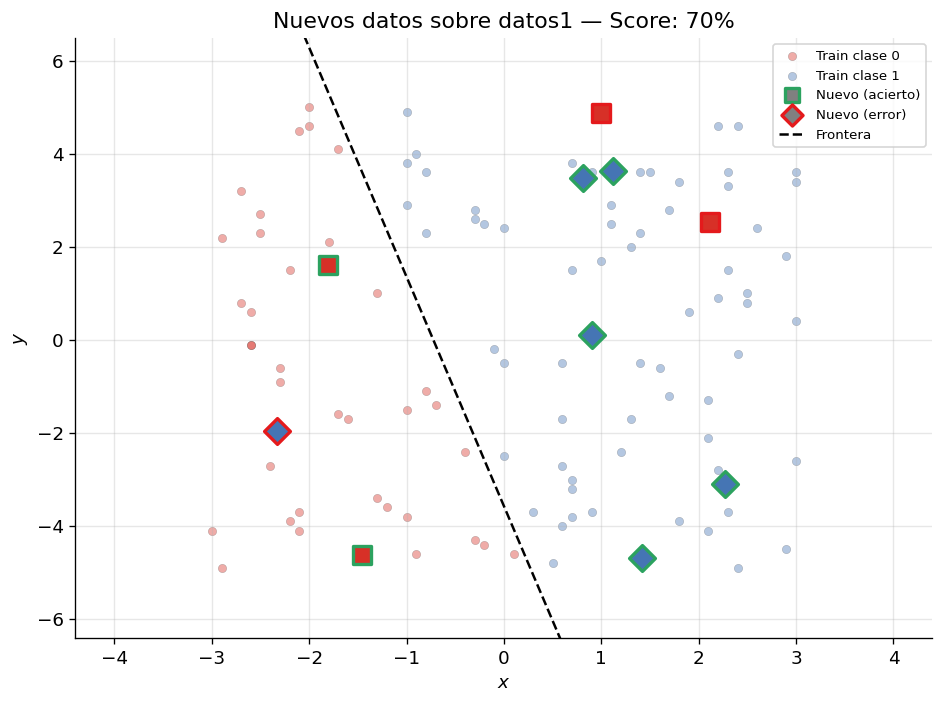

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#d73027', '#4575b4']
for label in [0, 1]:
    mask = y1 == label
    ax.scatter(X1[mask, 0], X1[mask, 1], c=colors[label], s=25,
               alpha=0.4, edgecolors='k', linewidths=0.2,
               label=f'Train clase {label}')

# Nuevos datos: borde verde si acertó, rojo si no
for i in range(len(new_data_scaled)):
    ec = '#2ca25f' if new_data_labels[i] == y_new_pred[i] else '#e41a1c'
    marker = 's' if new_data_labels[i] == 0 else 'D'
    ax.scatter(new_data_scaled[i, 0], new_data_scaled[i, 1],
               c=colors[new_data_labels[i]], s=120, marker=marker,
               edgecolors=ec, linewidths=2.0, zorder=5)

ax.scatter([], [], c='gray', s=80, marker='s', edgecolors='#2ca25f', linewidths=2, label='Nuevo (acierto)')
ax.scatter([], [], c='gray', s=80, marker='D', edgecolors='#e41a1c', linewidths=2, label='Nuevo (error)')

# Frontera
if abs(w1[2]) > 1e-10:
    xx = np.linspace(X1[:, 0].min() - 1, X1[:, 0].max() + 1, 300)
    yy = -(w1[0] + w1[1] * xx) / w1[2]
    ax.plot(xx, yy, 'k--', linewidth=1.5, label='Frontera')
    ax.set_ylim([X1[:, 1].min() - 1.5, X1[:, 1].max() + 1.5])

ax.set_title(f'Nuevos datos sobre datos1 — Score: {score_new:.0%}')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()


**Discusión.** El Perceptrón es un clasificador lineal, así que solo funciona bien cuando los datos son **linealmente separables**.
 En `datos1` logra 100% porque las clases se separan con una recta. En `datos2` el score es bajo (55%) porque las clases no son linealmente separables y el algoritmo no converge.

Los nuevos datos generados aleatoriamente no siguen la distribución de los datos de entrenamiento, por lo que el score baja.
 Los puntos con borde verde son aciertos y los de borde rojo son errores.
 Esto muestra que el Perceptrón es útil para problemas simples pero no puede modelar fronteras no lineales.


---
## Problema 5 · Descomposición en valores singulares  
**(5 puntos)**


> **Enunciado.** Muestre que para $A \in \mathbb{R}^{m \times n}$ con valores singulares
> $\sigma_1, \dots, \sigma_p$, $p = \min\{m, n\}$, se cumple
>
> $$\|A\|_F = \sqrt{\sigma_1^2 + \cdots + \sigma_p^2}.$$
>
> Verifique para la matriz  
> $A = \begin{pmatrix} 4 & 1 & 0 \\ 1 & 4 & 1 \\ 0 & 1 & 4 \end{pmatrix}$.


### Demostración

Sea $A = U\Sigma V^{\!\top}$ la SVD de $A$, con $U$, $V$ matrices ortogonales y $\Sigma$ la matriz diagonal de valores singulares.

Usamos que $\|A\|_F^2 = \mathrm{tr}(A^{\!\top}\!A)$ y que la traza es invariante cíclica:

$$
\|A\|_F^2
= \mathrm{tr}(A^{\!\top}\!A)
= \mathrm{tr}\!\bigl(V\Sigma^{\!\top}U^{\!\top}U\Sigma V^{\!\top}\bigr)
= \mathrm{tr}\!\bigl(V\Sigma^{\!\top}\Sigma V^{\!\top}\bigr)
= \mathrm{tr}\!\bigl(\Sigma^{\!\top}\Sigma V^{\!\top}V\bigr)
= \mathrm{tr}\!\bigl(\Sigma^{\!\top}\Sigma\bigr).
$$

La matriz $\Sigma^{\!\top}\Sigma \in \mathbb{R}^{n\times n}$ es diagonal con entradas $\sigma_1^2, \dots, \sigma_p^2$ (y ceros si $n > m$). Luego:

$$
\|A\|_F^2 = \sigma_1^2 + \sigma_2^2 + \cdots + \sigma_p^2
\qquad \Longrightarrow \qquad
\boxed{\;\|A\|_F = \sqrt{\sigma_1^2 + \cdots + \sigma_p^2}\;}
\qquad \blacksquare
$$


### Verificación numérica


In [25]:
A = np.array([
    [4, 1, 0],
    [1, 4, 1],
    [0, 1, 4]
], dtype=float)

U, sigma, Vt = svd(A)

frob_direct = norm(A, 'fro')
frob_svd    = np.sqrt(np.sum(sigma**2))

print('Matriz A:')
print(A)
print(f'\nValores singulares: {sigma}')
print(f'\n||A||_F (directo)    = {frob_direct:.10f}')
print(f'sqrt(sum sigma_i^2) = {frob_svd:.10f}')
print(f'Diferencia           = {abs(frob_direct - frob_svd):.2e}')


Matriz A:
[[4. 1. 0.]
 [1. 4. 1.]
 [0. 1. 4.]]

Valores singulares: [5.414214 4.       2.585786]

||A||_F (directo)    = 7.2111025509
sqrt(sum sigma_i^2) = 7.2111025509
Diferencia           = 8.88e-16


In [26]:
# Verificamos que A = U Sigma V^T
A_recon = U @ np.diag(sigma) @ Vt
print(f'Error de reconstrucción ||A - USV^T||_F = {norm(A - A_recon, "fro"):.2e}')
print(f'U ortogonal: {np.allclose(U @ U.T, np.eye(3))}')
print(f'V ortogonal: {np.allclose(Vt @ Vt.T, np.eye(3))}')


Error de reconstrucción ||A - USV^T||_F = 2.79e-15
U ortogonal: True
V ortogonal: True


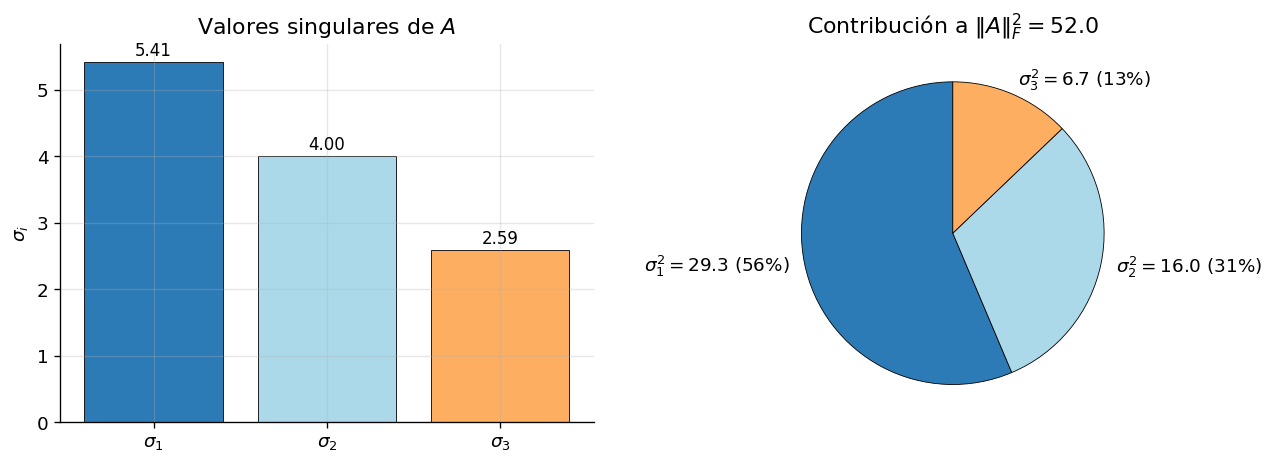

In [27]:
# Contribución de cada valor singular a la norma
sigma_sq = sigma**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
bars = ax.bar(['$\\sigma_1$', '$\\sigma_2$', '$\\sigma_3$'], sigma,
              color=['#2c7bb6', '#abd9e9', '#fdae61'], edgecolor='k', linewidth=0.5)
for bar, s in zip(bars, sigma):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{s:.2f}', ha='center', fontsize=10)
ax.set_title('Valores singulares de $A$')
ax.set_ylabel('$\\sigma_i$')

ax = axes[1]
pct = sigma_sq / sigma_sq.sum() * 100
labels_pie = [f'$\\sigma_{i+1}^2 = {s:.1f}$ ({p:.0f}%)' for i, (s, p) in enumerate(zip(sigma_sq, pct))]
ax.pie(sigma_sq, labels=labels_pie, colors=['#2c7bb6', '#abd9e9', '#fdae61'],
       startangle=90, wedgeprops={'edgecolor': 'k', 'linewidth': 0.5})
ax.set_title(f'Contribución a $\\|A\\|_F^2 = {sigma_sq.sum():.1f}$')

plt.tight_layout()
plt.show()


---
## Problema 6 · Análisis de Componentes Principales (PCA)  
**(15 puntos)**

> Considere la base de datos MNIST.
> **a)** Calcule la SVD de la matriz de datos.
> **b)** Reduzca la dimensión a la mitad (PCA).
> **c)** Grafique 10 imágenes y sus proyecciones.
> **d)** Calcule k-means sobre los datos proyectados y compare con P2.

### 6 a) SVD de la matriz MNIST

In [28]:
# Centramos los datos restando la media por columna
mu = X_mnist.mean(axis=0)
X_centered = X_mnist - mu

# SVD (economy / reduced para no gastar memoria con 70000x70000)
U_m, sigma_m, Vt_m = np.linalg.svd(X_centered, full_matrices=False)

print(f'U  : {U_m.shape}')
print(f'Σ  : {sigma_m.shape}')
print(f'V^T: {Vt_m.shape}')
print(f'Top-5 valores singulares: {sigma_m[:5].round(2)}')

U  : (70000, 784)
Σ  : (784,)
V^T: (784, 784)
Top-5 valores singulares: [599.89 514.01 476.51 446.67 424.88]


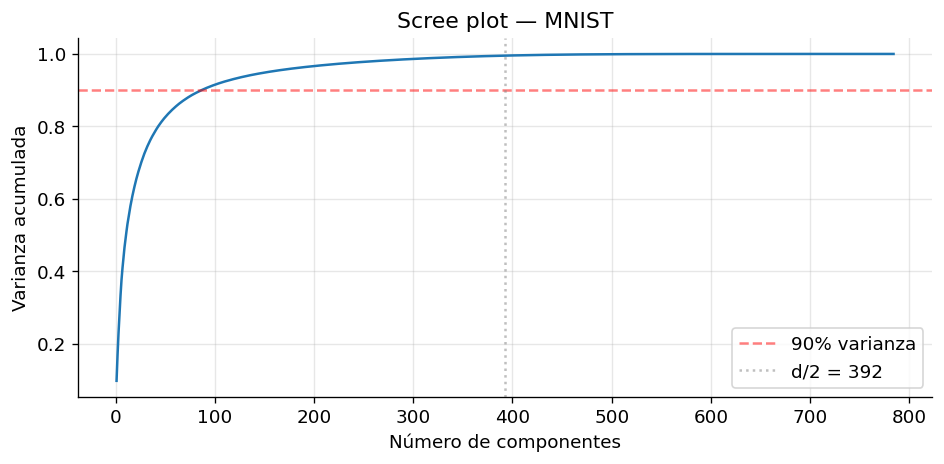

Con 392 componentes se retiene 99.5% de la varianza


In [29]:
# Varianza explicada
var_explicada = sigma_m**2 / np.sum(sigma_m**2)
var_acumulada = np.cumsum(var_explicada)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(var_acumulada)+1), var_acumulada, '-')
ax.axhline(0.9, color='r', ls='--', alpha=0.5, label='90% varianza')
ax.axvline(392, color='gray', ls=':', alpha=0.5, label='d/2 = 392')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada')
ax.set_title('Scree plot — MNIST')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Con 392 componentes se retiene {var_acumulada[391]*100:.1f}% de la varianza')

### 6 b) Reducción de dimensión a la mitad (PCA con $d/2 = 392$ componentes)

In [30]:
d_half = X_mnist.shape[1] // 2  # 392

# Proyección: X_proj = X_centered @ V_k (primeras d_half columnas de V)
V_k = Vt_m[:d_half].T  # shape (784, 392)
X_proj = X_centered @ V_k

print(f'Dimensión original : {X_mnist.shape[1]}')
print(f'Dimensión reducida : {X_proj.shape[1]}')
print(f'Varianza retenida  : {var_acumulada[d_half - 1]*100:.1f}%')

Dimensión original : 784
Dimensión reducida : 392
Varianza retenida  : 99.5%


### 6 c) Comparación visual: imágenes originales vs reconstruidas desde PCA

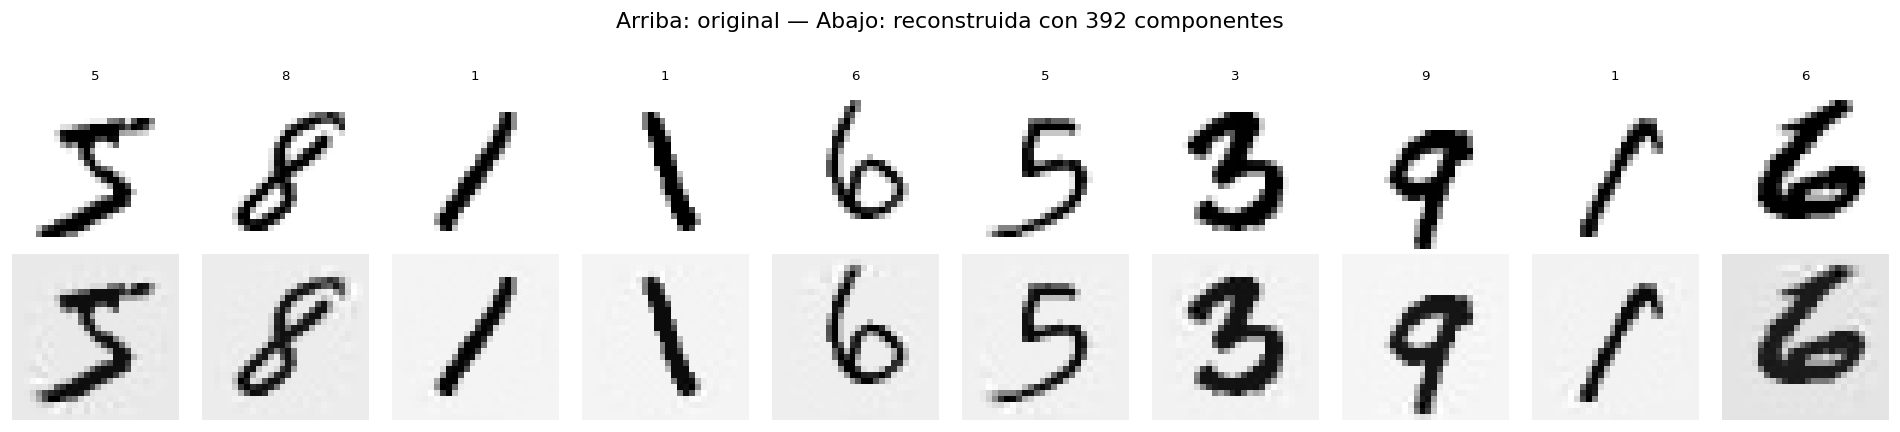

In [31]:
# Reconstruir desde la proyección: X_recon = X_proj @ V_k^T + mu
X_recon = X_proj @ V_k.T + mu

indices_ej = np.linspace(0, X_mnist.shape[0]-1, 10, dtype=int)

fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
for i, idx in enumerate(indices_ej):
    axes[0, i].imshow(X_mnist[idx].reshape(28, 28), cmap='gray_r')
    axes[0, i].set_title(f'{y_mnist[idx]}', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(X_recon[idx].reshape(28, 28), cmap='gray_r')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('PCA 392', fontsize=9)
fig.suptitle('Arriba: original — Abajo: reconstruida con 392 componentes', y=1.02)
plt.tight_layout()
plt.show()

### 6 d) K-means sobre los datos proyectados y comparación con P2c

In [32]:
# K-means sobre datos con PCA (dimensión 392)
rng_p = np.random.default_rng(123)  # misma semilla que P2c
idx0_pca = rng_p.choice(X_proj.shape[0], k_mnist, replace=False)
Z0_pca = X_proj[idx0_pca].copy()

Z_pca, labels_pca, J_pca = k_means_fit(X_proj, Z0_pca, 50)
print(f'PCA — Convergencia en {len(J_pca)} iteraciones, J final = {J_pca[-1]:.2f}')
print(f'Original — Convergencia en {len(J_mnist)} iteraciones, J final = {J_mnist[-1]:.2f}')

PCA — Convergencia en 50 iteraciones, J final = 2446522.48
Original — Convergencia en 50 iteraciones, J final = 2463961.87


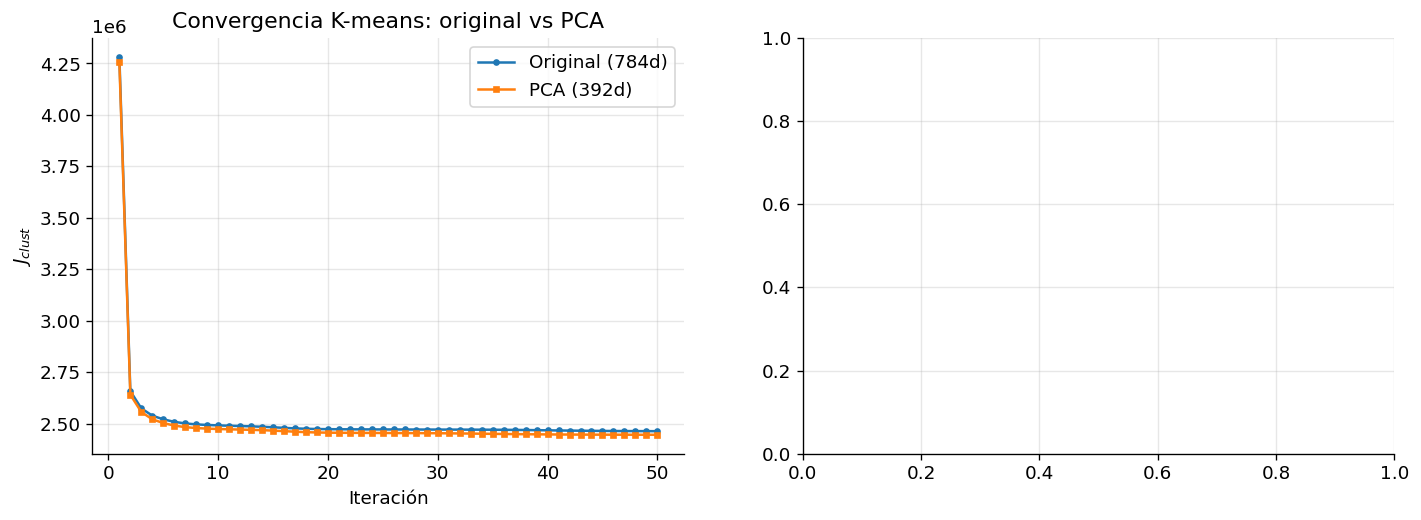

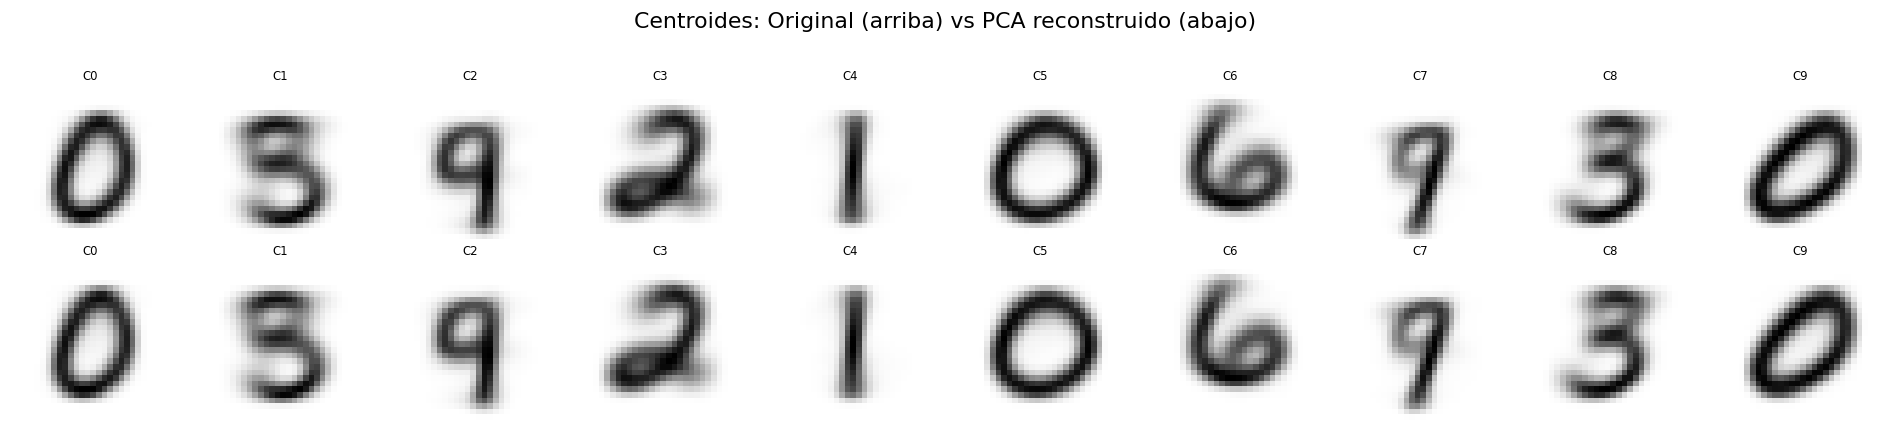

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(range(1, len(J_mnist)+1), J_mnist, 'o-', ms=3, label='Original (784d)')
axes[0].plot(range(1, len(J_pca)+1), J_pca, 's-', ms=3, label='PCA (392d)')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('$J_{clust}$')
axes[0].set_title('Convergencia K-means: original vs PCA')
axes[0].legend()

# Centroides PCA reconstruidos a 784d para visualizar
Z_pca_recon = Z_pca @ V_k.T + mu

for j in range(min(10, k_mnist)):
    axes[1].clear() if j == 0 else None

fig2, axes2 = plt.subplots(2, 10, figsize=(16, 3.5))
for j in range(10):
    axes2[0, j].imshow(Z_mnist[j].reshape(28, 28), cmap='gray_r')
    axes2[0, j].set_title(f'C{j}', fontsize=7)
    axes2[0, j].axis('off')

    axes2[1, j].imshow(Z_pca_recon[j].reshape(28, 28), cmap='gray_r')
    axes2[1, j].set_title(f'C{j}', fontsize=7)
    axes2[1, j].axis('off')

axes2[0, 0].set_ylabel('784d', fontsize=9)
axes2[1, 0].set_ylabel('PCA', fontsize=9)
fig2.suptitle('Centroides: Original (arriba) vs PCA reconstruido (abajo)', y=1.02)
plt.tight_layout()
plt.show()

**Comparación.** Al reducir la dimensionalidad a la mitad, el clustering converge
en un número similar de iteraciones pero el valor de $J_{\text{clust}}$ es menor
porque los datos viven en un espacio de menor dimensión. Los centroides
reconstruidos desde PCA se ven ligeramente más borrosos que los originales,
pero conservan la forma reconocible de los dígitos. Esto confirma que las primeras
392 componentes principales capturan la mayor parte de la estructura de los datos.

En la práctica, PCA antes de K-means es ventajoso porque: (1) reduce el tiempo
de cómputo por iteración, (2) elimina dimensiones ruidosas, y (3) produce
clusters de calidad comparable o incluso mejor al trabajar sobre la señal y no el ruido.